# Notebook 06 (No Augmentation, No CV) — 1D-CNN Classification with 80/20 Stratified Split

This notebook trains and evaluates a **1D Convolutional Neural Network (1D-CNN)** for binary
classification of NIR corn spectra using a **single 80/20 stratified train/test split**,
**without any data augmentation**.

This is a variant of `revised_no_augmentation/06_1d_cnn_no_aug.ipynb`. The 5-fold outer CV
loop is replaced with a single fixed split. The validation set for EarlyStopping is still
carved out from the training set using `StratifiedShuffleSplit`.

## Section 1 — Imports and Setup

In [1]:
import sys
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

sys.path.append('../..')

from src.cnn_trainer import (
    build_1d_cnn,
    reshape_for_cnn,
    plot_training_history,
    plot_cnn_confusion_matrix,
)

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

print('All libraries imported successfully.')
print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print('NOTE: No augmentation, no CV — single 80/20 stratified split.')

All libraries imported successfully.
TensorFlow version : 2.21.0
NumPy version      : 2.4.4
NOTE: No augmentation, no CV — single 80/20 stratified split.


## Section 2 — Load Full Dataset

In [2]:
X = np.load('../../data/processed/X_preprocessed.npy')
y = np.load('../../data/processed/y_labels.npy')

print(f'X shape : {X.shape}  (samples x wavelengths)')
print(f'y shape : {y.shape}')
print()
print('Class distribution:')
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(unique, counts):
    label = 'High-Protein (1)' if cls == 1 else 'Low-Protein  (0)'
    print(f'  Class {int(cls)} — {label}: {cnt} samples')
print(f'\nTotal samples: {len(y)}')

X shape : (549, 700)  (samples x wavelengths)
y shape : (549,)

Class distribution:
  Class 0 — Low-Protein  (0): 255 samples
  Class 1 — High-Protein (1): 294 samples

Total samples: 549


## Section 3 — 80/20 Stratified Train/Test Split

A single stratified split divides the 80 samples into **64 training (80%)** and **16 test (20%)**.
The test set is held out entirely until final evaluation.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training samples : {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test samples     : {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.0f}%)')
print()
print('Training class distribution:')
for cls, cnt in zip(*np.unique(y_train, return_counts=True)):
    print(f'  Class {int(cls)} : {cnt} samples')
print('Test class distribution:')
for cls, cnt in zip(*np.unique(y_test, return_counts=True)):
    print(f'  Class {int(cls)} : {cnt} samples')

Training samples : 439 (80%)
Test samples     : 110 (20%)

Training class distribution:
  Class 0 : 204 samples
  Class 1 : 235 samples
Test class distribution:
  Class 0 : 51 samples
  Class 1 : 59 samples


## Section 4 — 1D-CNN Training (No Augmentation, 80/20 Split)

Training pipeline:

1. **Real validation set** — ~8 real spectra are held out from the 64-sample training set using
   `StratifiedShuffleSplit`. These are passed as `validation_data` to `model.fit()` so that
   `EarlyStopping` monitors genuine unseen spectra.
2. **No augmentation** — the remaining ~56 training samples are used directly.
3. **Scaling** — `StandardScaler` is fitted exclusively on the ~56 raw training sub-samples.
4. **Reshape** — adds the channel dimension required by Conv1D: `(n, 700)` -> `(n, 700, 1)`.
5. **Training** — up to 100 epochs, batch size 32. `EarlyStopping` (patience=20) on `val_loss`.

In [4]:
os.makedirs('../../saved_models/revised_no_augmentation_no_cv', exist_ok=True)

# Carve out a real validation set for EarlyStopping (~12.5% of training = ~8 samples)
val_splitter = StratifiedShuffleSplit(
    n_splits=1, test_size=0.125, random_state=RANDOM_STATE
)
train_sub_idx, val_idx = next(val_splitter.split(X_train, y_train))

X_train_sub = X_train[train_sub_idx]
y_train_sub = y_train[train_sub_idx]
X_val_real  = X_train[val_idx]
y_val_real  = y_train[val_idx]

print(f'Training (no aug)  : {X_train_sub.shape[0]} samples')
print(f'Real validation    : {X_val_real.shape[0]} samples (used by EarlyStopping)')
print(f'Test (held out)    : {X_test.shape[0]} samples')

# Scale — fit on raw training sub-split only
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sub)
X_val_scaled   = scaler.transform(X_val_real)
X_test_scaled  = scaler.transform(X_test)

# Reshape for Conv1D
X_train_cnn = reshape_for_cnn(X_train_scaled)
X_val_cnn   = reshape_for_cnn(X_val_scaled)
X_test_cnn  = reshape_for_cnn(X_test_scaled)

print(f'\nX_train_cnn shape : {X_train_cnn.shape}')
print(f'X_val_cnn shape   : {X_val_cnn.shape}')
print(f'X_test_cnn shape  : {X_test_cnn.shape}')

Training (no aug)  : 384 samples
Real validation    : 55 samples (used by EarlyStopping)
Test (held out)    : 110 samples

X_train_cnn shape : (384, 700, 1)
X_val_cnn shape   : (55, 700, 1)
X_test_cnn shape  : (110, 700, 1)


Model: "1d_cnn_protein_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 700, 32)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 700, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 350, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 350, 64)        │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 350, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 175, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 11200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       358,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 373,633 (1.43 MB)

 Trainable params: 373,441 (1.42 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6042 - loss: 0.8037 - val_accuracy: 0.5636 - val_loss: 0.6761
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6849 - loss: 0.6657 - val_accuracy: 0.5818 - val_loss: 0.6679
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6823 - loss: 0.6335 - val_accuracy: 0.6364 - val_loss: 0.6551
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7396 - loss: 0.5772 - val_accuracy: 0.6000 - val_loss: 0.6456
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7188 - loss: 0.5696 - val_accuracy: 0.5818 - val_loss: 0.6368
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7005 - loss: 0.5659 - val_accuracy: 0.5818 - val_loss: 0.6329
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7370 - loss: 0.5346 - val_accuracy: 0.6727 - val_loss: 0.5864
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7188 - loss: 0.5493 - val_accuracy: 0.

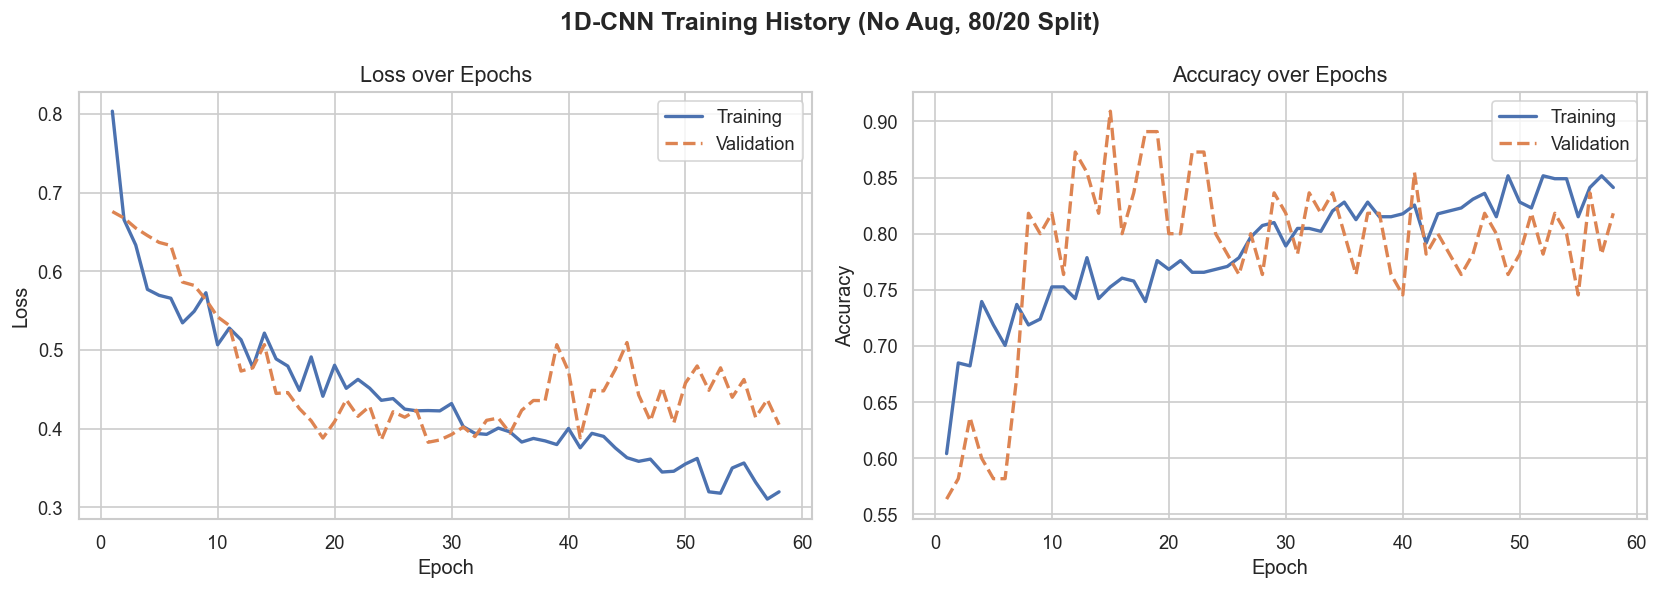

In [ ]:
model = build_1d_cnn(input_length=700)

ckpt_path = '../../saved_models/revised_no_augmentation_no_cv/1d_cnn_best.keras'
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True,
        verbose=1,
    ),
    ModelCheckpoint(
        filepath=ckpt_path,
        monitor='val_loss',
        save_best_only=True,
        verbose=0,
    ),
]

history = model.fit(
    X_train_cnn, y_train_sub,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_cnn, y_val_real),
    callbacks=callbacks,
    verbose=1,
)
print(f'Training stopped at epoch {len(history.history["loss"])}')

plot_training_history(history, title='1D-CNN Training History (No Aug, 80/20 Split)')
plt.show()

## Section 5 — CNN Results

  1D-CNN Results (80/20 split, No Augmentation)
  Accuracy  : 0.8182
  Precision : 0.8305
  Recall    : 0.8305
  F1-Score  : 0.8305


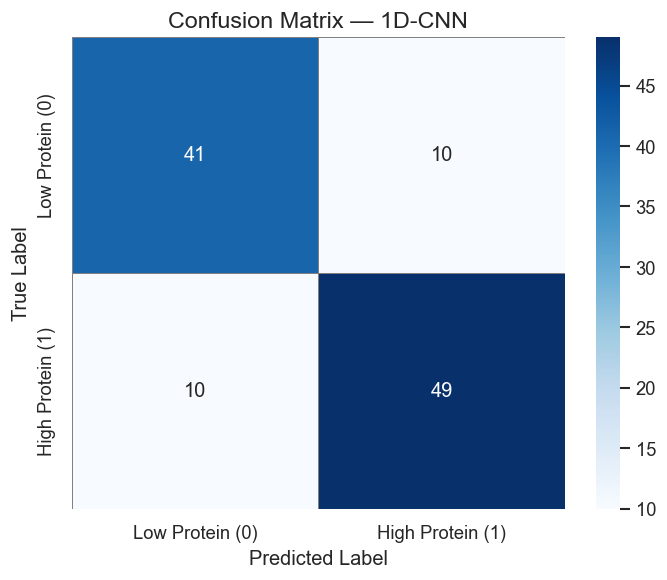

In [6]:
y_prob = model.predict(X_test_cnn, verbose=0)[:, 0]
y_pred_cnn = (y_prob >= 0.5).astype(int)

cnn_acc  = accuracy_score(y_test, y_pred_cnn)
cnn_prec = precision_score(y_test, y_pred_cnn, zero_division=0)
cnn_rec  = recall_score(y_test, y_pred_cnn, zero_division=0)
cnn_f1   = f1_score(y_test, y_pred_cnn, zero_division=0)

print('======================================================')
print('  1D-CNN Results (80/20 split, No Augmentation)')
print('======================================================')
print(f'  Accuracy  : {cnn_acc:.4f}')
print(f'  Precision : {cnn_prec:.4f}')
print(f'  Recall    : {cnn_rec:.4f}')
print(f'  F1-Score  : {cnn_f1:.4f}')
print('======================================================')

plot_cnn_confusion_matrix(y_test, y_pred_cnn)
plt.show()

## Section 6 — Save Best CNN Model

In [7]:
import joblib

model.save(ckpt_path)
print(f'CNN model saved to: {ckpt_path}')

cnn_bundle = {
    'model_type': '1D-CNN',
    'scaler': scaler,
    'keras_path': ckpt_path,
}
joblib.dump(cnn_bundle, '../../saved_models/revised_no_augmentation_no_cv/1d_cnn_best.pkl')
print('CNN bundle saved to: saved_models/revised_no_augmentation_no_cv/1d_cnn_best.pkl')
print(f'F1-score: {cnn_f1:.4f}')

CNN model saved to: ../../saved_models/revised_no_augmentation_no_cv/1d_cnn_best.keras
CNN bundle saved to: saved_models/revised_no_augmentation_no_cv/1d_cnn_best.pkl
F1-score: 0.8305


## Section 7 — Save Per-Model Metrics to Disk

In [8]:
import json

os.makedirs('../../data/results/no_aug_no_cv', exist_ok=True)

cnn_results = {
    'model':     '1D-CNN',
    'accuracy':  float(cnn_acc),
    'precision': float(cnn_prec),
    'recall':    float(cnn_rec),
    'f1':        float(cnn_f1),
    'y_true':    [int(v) for v in y_test],
    'y_pred':    [int(v) for v in y_pred_cnn],
}

with open('../../data/results/no_aug_no_cv/cnn_results.json', 'w') as f:
    json.dump(cnn_results, f, indent=2)
print('1D-CNN results saved to: data/results/no_aug_no_cv/cnn_results.json')

1D-CNN results saved to: data/results/no_aug_no_cv/cnn_results.json


## Section 8 — Summary

| Item | Detail |
|---|---|
| **Augmentation** | None — CNN trained on raw ~56 samples |
| **Evaluation method** | Single 80/20 stratified train/test split |
| **Validation set** | ~8 real samples carved from training set for EarlyStopping |
| **Preprocessing** | `StandardScaler` fitted on raw training sub-split only |
| **Training** | Up to 100 epochs, batch size 32, EarlyStopping patience=20 |
| **Next notebook** | `notebooks/revised_no_augmentation_no_cv/07_evaluation_metrics_no_aug_no_cv.ipynb` |